In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt

def leastSquareMethod(X, Y):
    n = len(X)
    xSum = sum(X[i] for i in range(n))
    x2Sum = sum(X[i]**2 for i in range(n))
    ySum = sum(Y[i] for i in range(n))
    xySum = sum(Y[i]*X[i] for i in range(n))
    
    m = ((n*(xySum) - (xSum)*(ySum)))/(n*(x2Sum) - ((xSum)**2))
    c = (ySum - (m*xSum))/n
    
    return m, c


    

When it says revisit, I am assuming it wants me to do all the parts of Challenge 9, so I will start with part 1 and go forwards.

In [7]:
#Revisit from previous challenge 9 part 1:

import numpy as np
# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Python Least Squares: Slope: {m}, Intercept: {c}")

m, c = leastSquareMethod(X, Y)

print(f"My Function Least Squares: Slope: {m}, Intercept: {c}")

Python Least Squares: Slope: 0.9500000000000001, Intercept: 0.5900000000000001
My Function Least Squares: Slope: 0.95, Intercept: 0.5899999999999999


Through observation, my comparison between them would be that there is barely any difference between my function and Pythons slope/intercept

[0.01598882 0.07301965 0.24676034 0.69829835 0.98059516]
[0.78441425 0.25075805 0.65410266 0.15250833 0.27392725]
Slope: -0.4050640990385481, Intercept: 0.5863555828769321 
 Plot for my function below


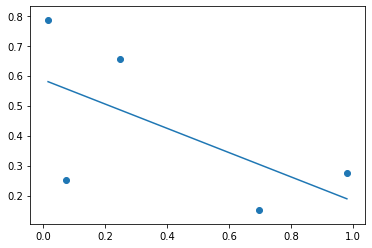

Slope: -0.4050640990385478, Intercept: 0.5863555828769318 
 Plot for Python function below


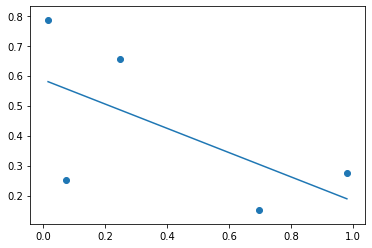

In [19]:
#Revisit from previous challenge 9 part 2:

def randomizeXY(N):
    randomX = []
    randomY = []
    for i in range(N):
        numXRand = random.uniform(0, 1)
        randomX.append(numXRand)
        numYRand = random.uniform(0, 1)
        randomY.append(numYRand)
        
    randomX.sort()
    return np.array(randomX), np.array(randomY) #Note: if you wanna do funky stuff with arrays, always use np

X, Y = randomizeXY(5)

print(X)
print(Y)

m, c = leastSquareMethod(X, Y)
print(f"Slope: {m}, Intercept: {c} \n Plot for my function below")

plt.scatter(X, Y)
plt.plot(X, m*X + c)
plt.show()

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c} \n Plot for Python function below")

plt.scatter(X, Y)
plt.plot(X, m*X + c)
plt.show()

Both are not fitted well for random X and Y vectors, and they are very similar in m/intercept values, with the difference being incredibly low

Below is the plot for my function


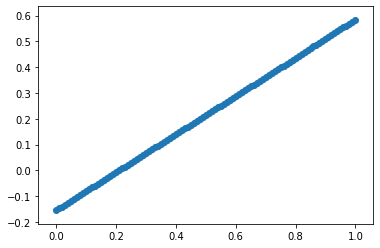

Original Equation: y = 0.738475077878297x + 0.10815058214619233 
Calculated Equation: y = 0.7384750778782975x + -0.1548440914798161 
3.3306690738754696e-16
0.0
Largest Residual: 3.3306690738754696e-16 at xAxis=0.96
Smallest Residual: 0.0 at xAxis=0.36

Below is the plot for Python Function


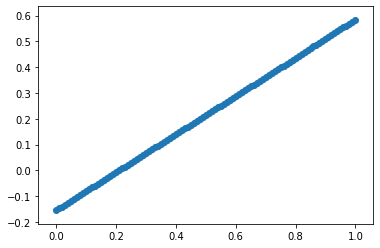

Original Equation: y = 0.738475077878297x + 0.10815058214619233 
Calculated Equation: y = 0.738475077878297x + -0.154844091479816 
1.1102230246251565e-16
0.0
Largest Residual: 1.1102230246251565e-16 at xAxis=0.02
Smallest Residual: 0.0 at xAxis=0.55


In [26]:
#Revisit from previous challenge 9 part 3:

xAxis = np.arange(0, 1.01, 0.01)
mRand = random.uniform(0, 1)
bRand = random.uniform(0, 1)
randomNumber = random.uniform(0, 1)
def negPos():
    randomNum = random.uniform(0,1)
    if randomNum > 0.5:
        return 1
    else:
        return -1

yAxis = mRand*xAxis + bRand + (negPos()*randomNumber)

m, c = leastSquareMethod(xAxis, yAxis)

yCalc = m*xAxis + c
residuals = abs(yAxis - yCalc)

maxError = max(residuals)
minError = min(residuals)

plt.scatter(xAxis, yAxis)
plt.plot(xAxis, yCalc)
print("Below is the plot for my function")
plt.show()
print(f"Original Equation: y = {mRand}x + {bRand} ")
print(f"Calculated Equation: y = {m}x + {c} ")
print(maxError)
print(minError)

idx_max = np.argmax(residuals) #argmax finds the index with largest value
idx_min = np.argmin(residuals) #argmin finds the index with lowest value
print(f"Largest Residual: {maxError} at xAxis={xAxis[idx_max]}")
print(f"Smallest Residual: {minError} at xAxis={xAxis[idx_min]}\n")


#--------------------------------------------------------------------------------------------------------------------------
#This is now for Python Function:

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([xAxis, np.ones(len(xAxis))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, yAxis, rcond=None)[0]

yCalc = m*xAxis + c
residuals = abs(yAxis - yCalc)

maxError = max(residuals)
minError = min(residuals)

plt.scatter(xAxis, yAxis)
plt.plot(xAxis, yCalc)
print("Below is the plot for Python Function")
plt.show()
print(f"Original Equation: y = {mRand}x + {bRand} ")
print(f"Calculated Equation: y = {m}x + {c} ")
print(maxError)
print(minError)

idx_max = np.argmax(residuals) #argmax finds the index with largest value
idx_min = np.argmin(residuals) #argmin finds the index with lowest value
print(f"Largest Residual: {maxError} at xAxis={xAxis[idx_max]}")
print(f"Smallest Residual: {minError} at xAxis={xAxis[idx_min]}")


They both have very calculated equations, however they have different residual points and residual maxes.